### 1: Load a dataset

In [1]:
import pandas as pd
import numpy as np
import visualize_scores as visualize

In [2]:
scores = pd.read_csv("scores_all.csv")

scores.head(10)

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
0,p0,A1,generate,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
1,p0,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
2,p0,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
3,p0,A1,generate,claude,chatgpt,4.0,3.0,3.0,3.0,3.0,16.0,False,False,False,False,False,False
4,p0,A1,generate,claude,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
5,p0,A1,generate,claude,grok,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
6,p0,A1,generate,gemini,chatgpt,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
7,p0,A1,generate,gemini,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
8,p0,A1,generate,gemini,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
9,p0,A1,generate,grok,chatgpt,3.0,3.0,2.0,3.0,3.0,14.0,False,False,False,False,False,False


In [3]:
p0_dataset = scores[scores['Prompt'] == "p0"]
p0_dataset.head(10)

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
0,p0,A1,generate,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
1,p0,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
2,p0,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
3,p0,A1,generate,claude,chatgpt,4.0,3.0,3.0,3.0,3.0,16.0,False,False,False,False,False,False
4,p0,A1,generate,claude,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
5,p0,A1,generate,claude,grok,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
6,p0,A1,generate,gemini,chatgpt,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
7,p0,A1,generate,gemini,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
8,p0,A1,generate,gemini,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
9,p0,A1,generate,grok,chatgpt,3.0,3.0,2.0,3.0,3.0,14.0,False,False,False,False,False,False


### 2: Writer Performance by Dimension (Average Dimension's Score)

In [4]:
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']

writers = ['chatgpt', 'claude', 'gemini', 'grok']

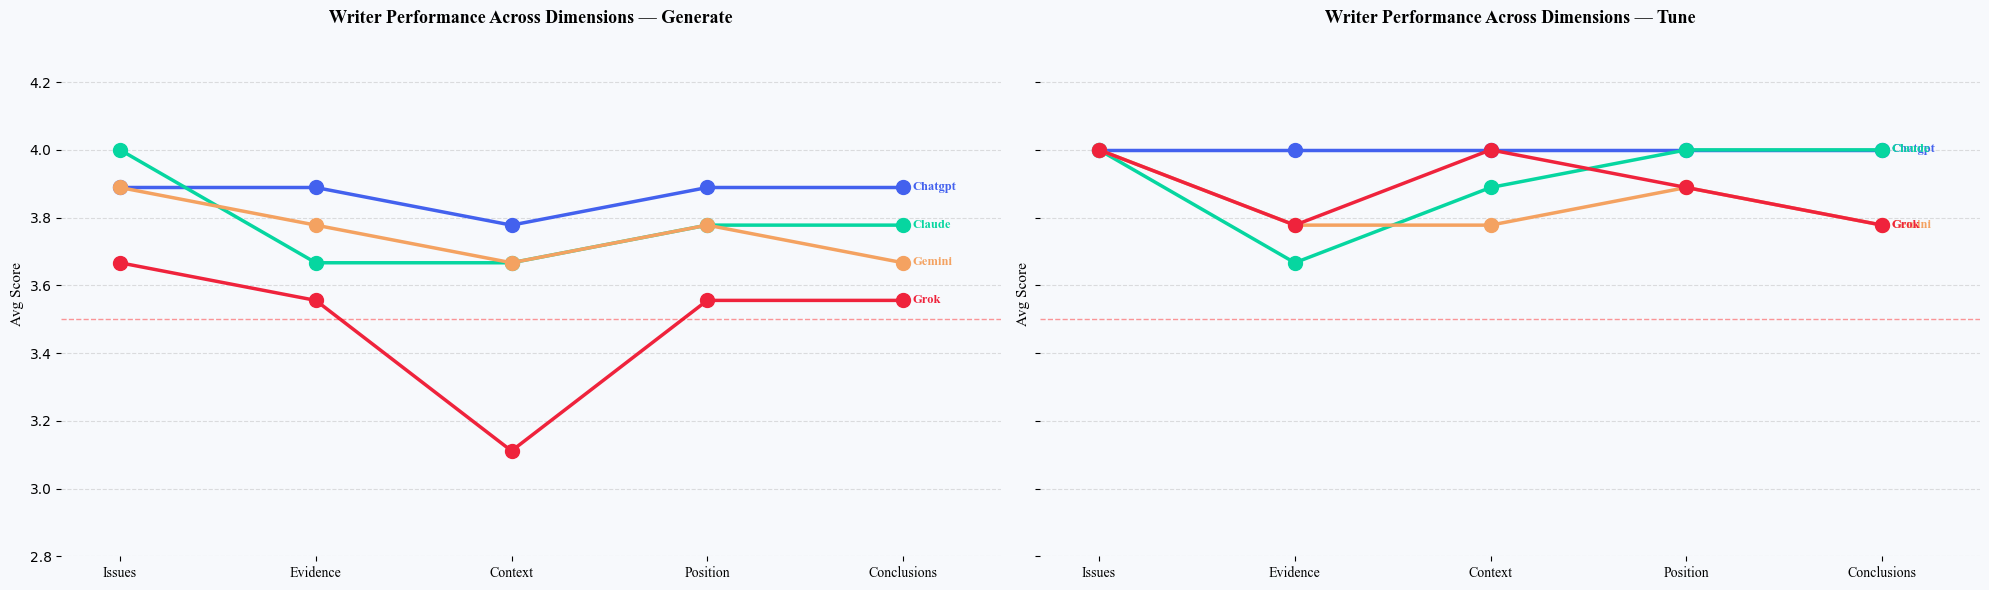

In [5]:
visualize.writer_performance_by_dimension_avg(p0_dataset, dimensions, writers)

In [77]:
chatgpt_writer = p0_dataset[p0_dataset['Writer'] == "chatgpt"]
chatgpt_writer

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
0,p0,A1,generate,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
1,p0,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
2,p0,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
12,p0,A1,tune,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
13,p0,A1,tune,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
14,p0,A1,tune,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
24,p0,A2,generate,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
25,p0,A2,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
26,p0,A2,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
36,p0,A2,tune,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False


In [63]:
def plot_grader_bias_by_writer(scores, writers, dimensions, target_writer=None):

    grader_colors = {
        'chatgpt': '#4361ee',
        'claude':  '#06d6a0',
        'gemini':  '#f4a261',
        'grok':    '#ef233c'
    }

    essay_types = ['generate', 'tune']

    targets = [target_writer] if target_writer else writers

    for writer in targets:

        fig, axes = plt.subplots(
            len(dimensions), 2,
            figsize=(12, len(dimensions) * 2),
            sharey=False
        )

        fig.patch.set_facecolor('#f7f9fc')

        for row, dimension in enumerate(dimensions):

            for col, etype in enumerate(essay_types):

                ax = axes[row][col]

                subset = scores[
                    (scores['EssayType'] == etype) &
                    (scores['Writer'] == writer)
                ]

                ax.set_facecolor('#f7f9fc')

                for i, grader in enumerate(writers):

                    g_subset = subset[subset['Grader'] == grader]

                    y_vals = g_subset[dimension].values

                    if len(y_vals) == 0:
                        continue

                    x_vals = np.random.normal(i, 0.04, size=len(y_vals))

                    ax.scatter(
                        x_vals, y_vals,
                        color=grader_colors[grader],
                        alpha=0.6, s=20, zorder=2
                    )

                ax.set_xticks(range(len(writers)))

                ax.set_ylim(0.0, 4.5)

                ax.set_yticks([0, 1.0, 2.0, 3.0, 4.0])

                ax.yaxis.grid(True, linestyle='--', alpha=0.3)

                ax.set_axisbelow(True)

                for spine in ax.spines.values():
                    spine.set_visible(False)

                # x labels only on bottom row
                if row < len(dimensions) - 1:
                    ax.tick_params(axis='x', labelbottom=False)
                else:
                    ax.set_xticklabels(
                        [w.capitalize() for w in writers],
                        fontfamily='Times New Roman',
                        fontsize=8
                    )

                # y label only on left column
                if col == 0:
                    ax.set_ylabel(
                        dimension,
                        fontfamily='Times New Roman',
                        fontsize=8,
                        fontweight='bold'
                    )
                    ax.tick_params(axis='y', labelsize=7)
                else:
                    ax.tick_params(axis='y', labelleft=False)

                # title only on top row
                if row == 0:
                    ax.set_title(
                        etype.capitalize(),
                        fontfamily='Times New Roman',
                        fontsize=10,
                        fontweight='bold'
                    )

        legend_elements = [
            Line2D(
                [0], [0],
                marker='o', color='w',
                markerfacecolor=grader_colors[g],
                markersize=8,
                label=g.capitalize() + ' (grader)'
            )
            for g in writers
        ]

        fig.legend(
            handles=legend_elements,
            loc='lower center',
            ncol=len(writers),
            fontsize=9,
            prop={'family': 'Times New Roman'},
            framealpha=0.5,
            bbox_to_anchor=(0.5, -0.02)
        )

        plt.suptitle(
            'Cross Grading Performance — ' + writer.capitalize() + ' Writer',
            fontfamily='Times New Roman',
            fontsize=13,
            fontweight='bold',
            y=1.01
        )

        plt.tight_layout(h_pad=0.4, w_pad=0.5)
        plt.show()

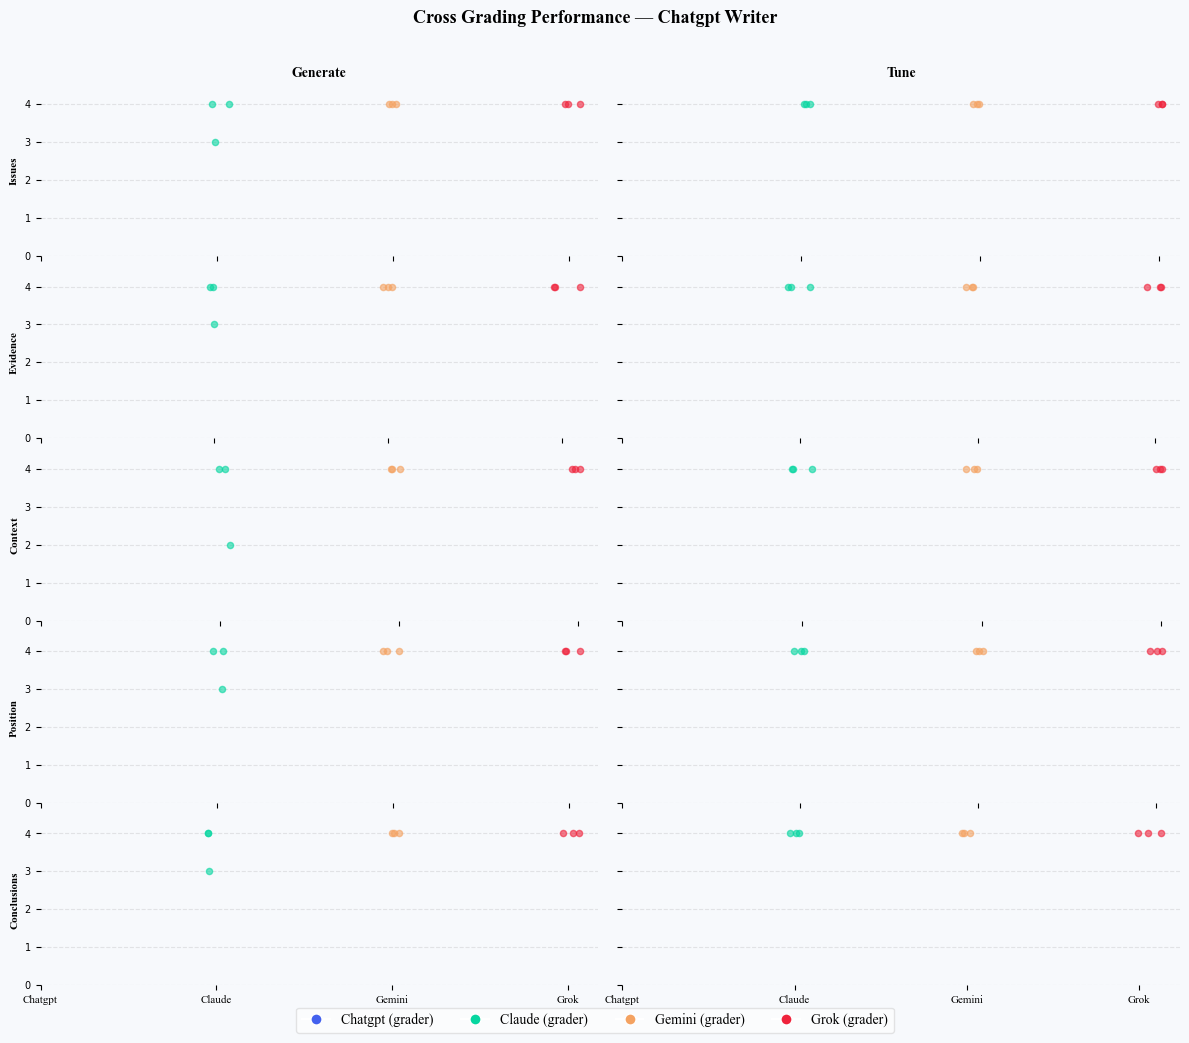

In [66]:
plot_grader_bias_by_writer(p0_dataset, writers, dimensions, target_writer='chatgpt')


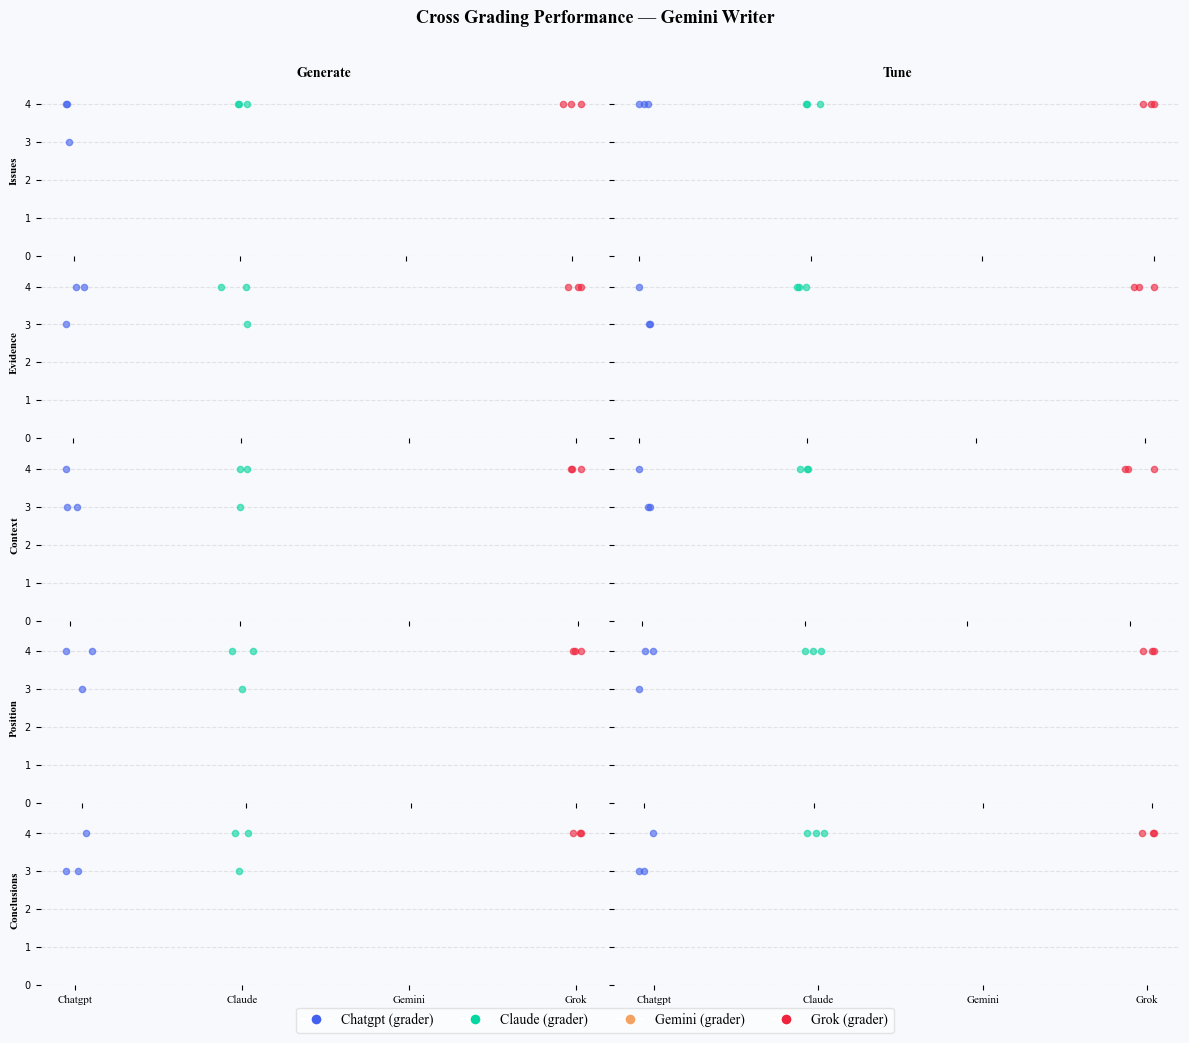

In [67]:
plot_grader_bias_by_writer(p0_dataset, writers, dimensions, target_writer='gemini')


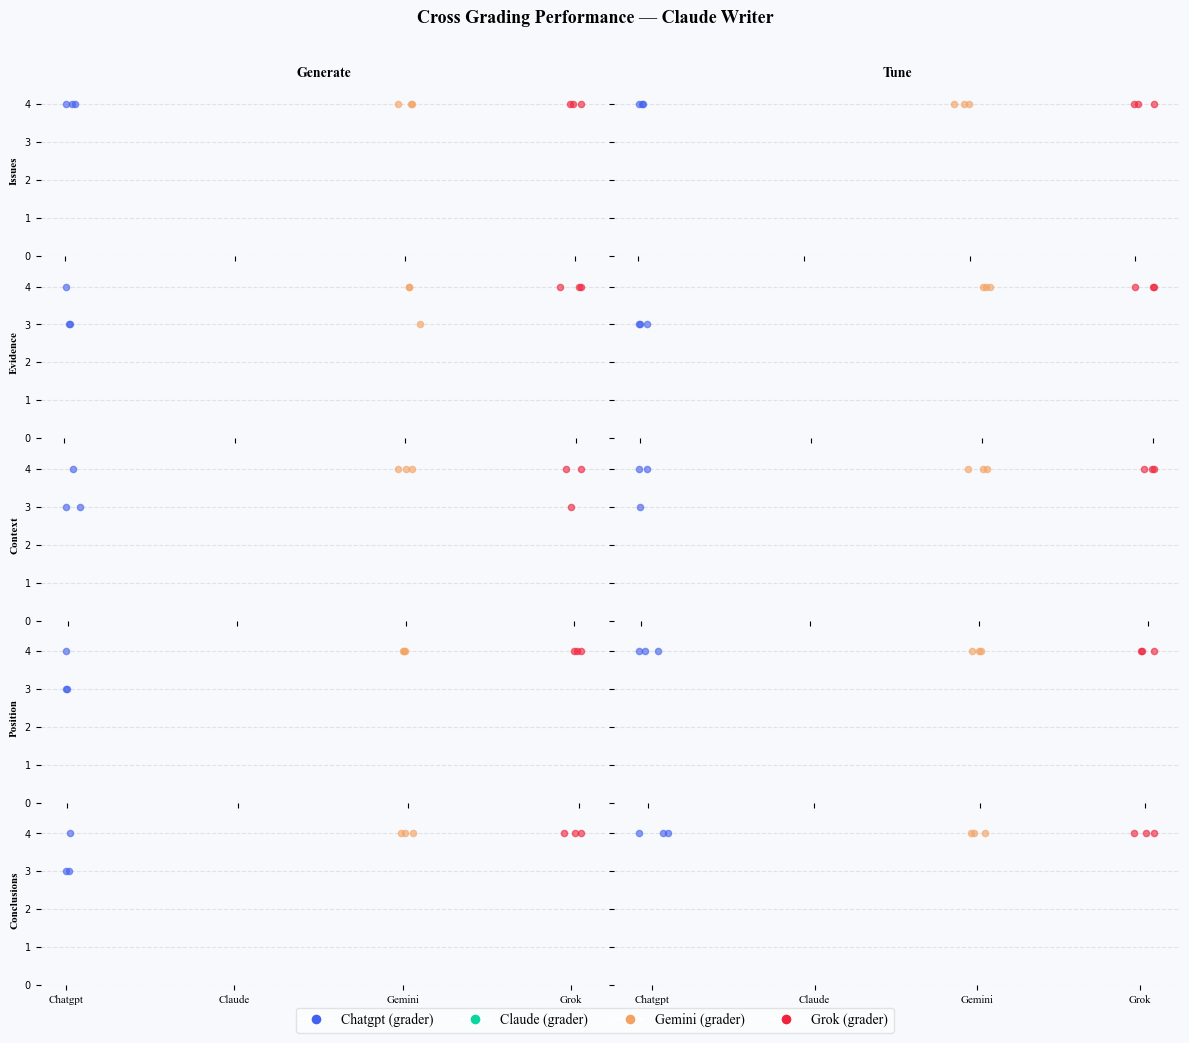

In [68]:
plot_grader_bias_by_writer(p0_dataset, writers, dimensions, target_writer='claude')


### 3. Writer Performance by Assignment 

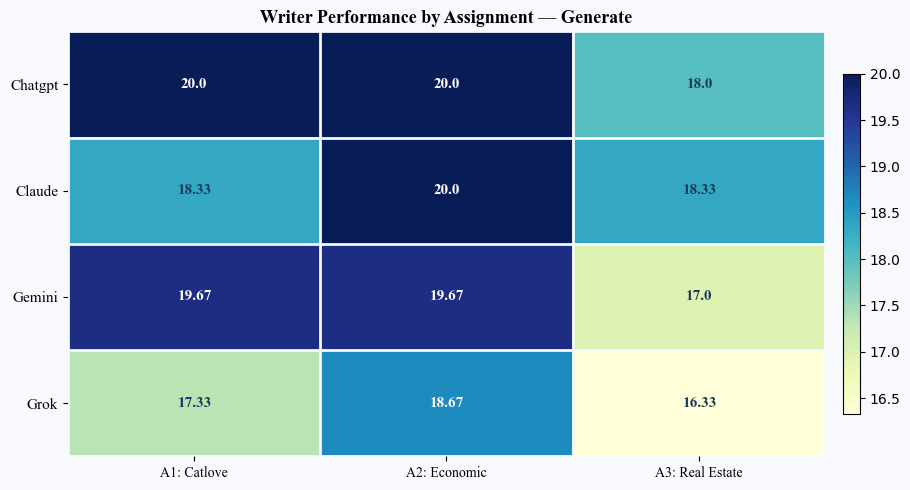

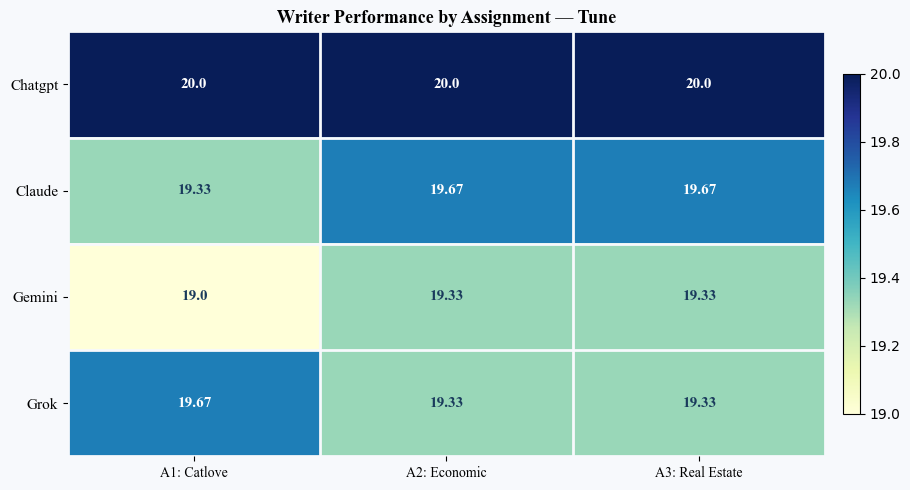

{'generate':          A1: Catlove  A2: Economic  A3: Real Estate
 Chatgpt        20.00         20.00            18.00
 Claude         18.33         20.00            18.33
 Gemini         19.67         19.67            17.00
 Grok           17.33         18.67            16.33,
 'tune':          A1: Catlove  A2: Economic  A3: Real Estate
 Chatgpt        20.00         20.00            20.00
 Claude         19.33         19.67            19.67
 Gemini         19.00         19.33            19.33
 Grok           19.67         19.33            19.33}

In [10]:
visualize.writer_performance_by_assignment(p0_dataset, writers)